## 한글분석과 워드클라우드

In [ ]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import os
import sys
import urllib.request
import time
import json

from dotenv import load_dotenv
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler 
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    ##  K-means 임포트
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
import re


import matplotlib.pyplot as plt
plt.rc('font',family='D2CodingLigature Nerd Font')
# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시

In [2]:
data = json.loads(open('../../data/아시안컵_naver_news.json', 'r' , encoding = 'utf-8').read())
data

[{'cnt': 1,
  'description': '<b>아시안컵</b>에 출전하는 풋살대표팀이 대회를 앞두고 국내 최종소집을 실시한다. 파울로 페르난데스 감독이 이끄는 풋살대표팀은12일부터 15일까지 경기도 이천에 위치한 LBFS 트레이닝센터에서 2026 AFC 풋살 <b>아시안컵</b>... ',
  'link': 'https://www.gukjenews.com/news/articleView.html?idxno=3478900',
  'org_link': 'https://www.gukjenews.com/news/articleView.html?idxno=3478900',
  'pDate': '2026-01-12 19:26:00',
  'title': '풋살대표팀, AFC 풋살 <b>아시안컵</b> 대비 최종소집 훈련 진행'},
 {'cnt': 2,
  'description': 'U20 <b>아시안컵</b> 축구 경기일정, 조편성, 중계 / KFA 제공 대한축구협회가 남자 20세 이하(U-20) 대표팀 감독을 공개채용 방식으로 선발한다. 각급연령별 대표팀 감독을 공개채용 하는 것은 이번이 처음이다. 협회는 보다... ',
  'link': 'https://www.gukjenews.com/news/articleView.html?idxno=3478899',
  'org_link': 'https://www.gukjenews.com/news/articleView.html?idxno=3478899',
  'pDate': '2026-01-12 19:26:00',
  'title': '대한축구협회, 남자 20세 이하 대표팀 감독 공개 채용'},
 {'cnt': 3,
  'description': '베트남 축구는 AFC U-23 <b>아시안컵</b> 대회에서 조별리그 3연승으로 통과한 적이 없었다. 그 역사적인 기록에... 베트남은 13일 오전 1시30분(한국시각) 사우디아라비아 제다에서 개최국 사우디와 2026년 AFC U-23 <b>아시안컵</b>... ',
  'li

In [4]:
import re

descriptions = []

for item in data:
    desc = item.get('description')
    if isinstance(desc, str):
        # 1. HTML 태그 제거
        desc = re.sub(r'<[^>]+>', ' ', desc)
        # 2. 한글, 영어, 공백만 남기기
        desc = re.sub(r'[^가-힣a-zA-Z0-9\s]', ' ', desc)
        # 3. 공백 정리
        desc = re.sub(r'\s+', ' ', desc).strip()

        descriptions.append(desc)

descriptions

['아시안컵 에 출전하는 풋살대표팀이 대회를 앞두고 국내 최종소집을 실시한다 파울로 페르난데스 감독이 이끄는 풋살대표팀은12일부터 15일까지 경기도 이천에 위치한 LBFS 트레이닝센터에서 2026 AFC 풋살 아시안컵',
 'U20 아시안컵 축구 경기일정 조편성 중계 KFA 제공 대한축구협회가 남자 20세 이하 U 20 대표팀 감독을 공개채용 방식으로 선발한다 각급연령별 대표팀 감독을 공개채용 하는 것은 이번이 처음이다 협회는 보다',
 '베트남 축구는 AFC U 23 아시안컵 대회에서 조별리그 3연승으로 통과한 적이 없었다 그 역사적인 기록에 베트남은 13일 오전 1시30분 한국시각 사우디아라비아 제다에서 개최국 사우디와 2026년 AFC U 23 아시안컵',
 '젠시티에 합류한 지프리 바이카뎀은 지난 FC 프로 챔피언스 컵 2025 결승에서 젠시티에 패배를 안겼던 천적 이자 지난해 동남 아시안 게임 금메달리스트로서 기대를 모은다 토비오 니와에 반야왓의 경우 2023년의',
 '한편 U 20 대표팀은 이번 공개 채용을 통해 선발되는 새로운 감독의 지휘 아래 2027년 3월 중국에서 개최되는 AFC U 20 아시안컵 을 준비하게 된다 아시안컵 예선은 올해 하반기에 열린다 아시안컵 에서 월드컵',
 '풋살 아시안컵 에 출전하는 풋살대표팀이 대회를 앞두고 국내 최종소집을 실시한다 파울로 페르난데스 감독이 이끄는 대표팀은 오는 12일부터 15일까지 경기도 이천 LBFS 트레이닝센터에서 2026 AFC 풋살 아시안컵',
 '한편 U 20 대표팀은 이번 공개채용을 통해 선발되는 새로운 감독의 지휘 아래 2027년 3월 중국에서 개최하는 U 20 아시안컵 출전을 준비할 예정이다 아시안컵 예선은 올해 하반기에 개최된다 아시안컵 에서 월드컵',
 '이달 말 아시아축구연맹 AFC 풋살 아시안컵 에 출전하는 풋살대표팀이 대회를 앞두고 국내 최종소집을 풋살 아시안컵 대비 최종소집을 진행한다고 밝혔다 풋살대표팀은 최종소집을 마친 뒤 16일 인천공항을',
 '한편 U 20 대표팀은 

In [6]:
words = [word for d in descriptions for word in d.split()]
words

['아시안컵',
 '에',
 '출전하는',
 '풋살대표팀이',
 '대회를',
 '앞두고',
 '국내',
 '최종소집을',
 '실시한다',
 '파울로',
 '페르난데스',
 '감독이',
 '이끄는',
 '풋살대표팀은12일부터',
 '15일까지',
 '경기도',
 '이천에',
 '위치한',
 'LBFS',
 '트레이닝센터에서',
 '2026',
 'AFC',
 '풋살',
 '아시안컵',
 'U20',
 '아시안컵',
 '축구',
 '경기일정',
 '조편성',
 '중계',
 'KFA',
 '제공',
 '대한축구협회가',
 '남자',
 '20세',
 '이하',
 'U',
 '20',
 '대표팀',
 '감독을',
 '공개채용',
 '방식으로',
 '선발한다',
 '각급연령별',
 '대표팀',
 '감독을',
 '공개채용',
 '하는',
 '것은',
 '이번이',
 '처음이다',
 '협회는',
 '보다',
 '베트남',
 '축구는',
 'AFC',
 'U',
 '23',
 '아시안컵',
 '대회에서',
 '조별리그',
 '3연승으로',
 '통과한',
 '적이',
 '없었다',
 '그',
 '역사적인',
 '기록에',
 '베트남은',
 '13일',
 '오전',
 '1시30분',
 '한국시각',
 '사우디아라비아',
 '제다에서',
 '개최국',
 '사우디와',
 '2026년',
 'AFC',
 'U',
 '23',
 '아시안컵',
 '젠시티에',
 '합류한',
 '지프리',
 '바이카뎀은',
 '지난',
 'FC',
 '프로',
 '챔피언스',
 '컵',
 '2025',
 '결승에서',
 '젠시티에',
 '패배를',
 '안겼던',
 '천적',
 '이자',
 '지난해',
 '동남',
 '아시안',
 '게임',
 '금메달리스트로서',
 '기대를',
 '모은다',
 '토비오',
 '니와에',
 '반야왓의',
 '경우',
 '2023년의',
 '한편',
 'U',
 '20',
 '대표팀은',
 '이번',
 '공개',
 '채용을',
 '통해',
 '선발되는',
 '새로운',
 '감독

In [7]:
word2 = [i for i in words if (len(i)>=2) & (len(i)<=6)]
word2

['아시안컵',
 '출전하는',
 '풋살대표팀이',
 '대회를',
 '앞두고',
 '국내',
 '최종소집을',
 '실시한다',
 '파울로',
 '페르난데스',
 '감독이',
 '이끄는',
 '15일까지',
 '경기도',
 '이천에',
 '위치한',
 'LBFS',
 '2026',
 'AFC',
 '풋살',
 '아시안컵',
 'U20',
 '아시안컵',
 '축구',
 '경기일정',
 '조편성',
 '중계',
 'KFA',
 '제공',
 '남자',
 '20세',
 '이하',
 '20',
 '대표팀',
 '감독을',
 '공개채용',
 '방식으로',
 '선발한다',
 '각급연령별',
 '대표팀',
 '감독을',
 '공개채용',
 '하는',
 '것은',
 '이번이',
 '처음이다',
 '협회는',
 '보다',
 '베트남',
 '축구는',
 'AFC',
 '23',
 '아시안컵',
 '대회에서',
 '조별리그',
 '3연승으로',
 '통과한',
 '적이',
 '없었다',
 '역사적인',
 '기록에',
 '베트남은',
 '13일',
 '오전',
 '1시30분',
 '한국시각',
 '제다에서',
 '개최국',
 '사우디와',
 '2026년',
 'AFC',
 '23',
 '아시안컵',
 '젠시티에',
 '합류한',
 '지프리',
 '바이카뎀은',
 '지난',
 'FC',
 '프로',
 '챔피언스',
 '2025',
 '결승에서',
 '젠시티에',
 '패배를',
 '안겼던',
 '천적',
 '이자',
 '지난해',
 '동남',
 '아시안',
 '게임',
 '기대를',
 '모은다',
 '토비오',
 '니와에',
 '반야왓의',
 '경우',
 '2023년의',
 '한편',
 '20',
 '대표팀은',
 '이번',
 '공개',
 '채용을',
 '통해',
 '선발되는',
 '새로운',
 '감독의',
 '지휘',
 '아래',
 '2027년',
 '3월',
 '중국에서',
 '개최되는',
 'AFC',
 '20',
 '아시안컵',
 '준비하게',
 '된다',
 '아시안컵',
 '예선은'

In [9]:
cnt = Counter(word2)
cnt

Counter({'아시안컵': 1189,
         '23': 868,
         'AFC': 649,
         '2026': 375,
         '이하': 306,
         '조별리그': 263,
         '23세': 245,
         '감독이': 221,
         '열린': 217,
         '아시안': 209,
         'C조': 201,
         '이민성': 187,
         '20': 186,
         '스타디움에서': 179,
         '이끄는': 164,
         'U23': 156,
         '7일': 145,
         '대표팀은': 144,
         'quot': 144,
         '클럽': 139,
         '한국': 134,
         '10일': 123,
         '월드컵': 122,
         '대한민국': 114,
         '한국시간': 112,
         'FIFA': 111,
         '알샤바브': 102,
         '게임': 101,
         '에서': 99,
         '오후': 98,
         '있다': 93,
         '이란과': 91,
         '1차전에서': 91,
         '지난': 88,
         '한국은': 87,
         '2023': 85,
         '2차전에서': 85,
         '0으로': 84,
         '2023년': 84,
         '리야드의': 84,
         '예선': 83,
         '나고야': 83,
         '항저우': 82,
         '아이치': 80,
         '금메달': 79,
         '2022년': 79,
         '준우승': 78,
         '리야드': 74,
   

In [11]:
wc = WordCloud(
    font_path='/home/erion/.local/share/fonts/d2codingligature-nerd-font/D2CodingLigatureNerdFont-Regular.ttf',  # 폰트 경로 필수!
    background_color='black',
    width=800,
    height=600,
    colormap='RdBu'
)

cloud = wc.generate_from_frequencies(cnt)

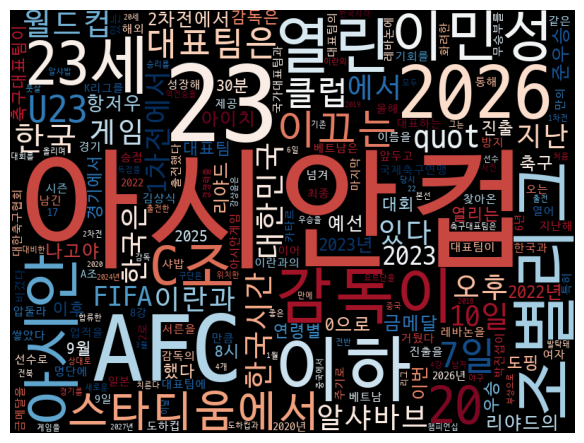

In [13]:
plt.imshow(cloud)
plt.axis('off')
# plt.savefig('../../data/아시안컵.png')
plt.show()